In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("classification_report_updated.csv")

In [4]:
cwe_category_map = {

"CWE121":"Memory",
"CWE122":"Memory",
"CWE124":"Memory",
"CWE415":"Memory",
"CWE416":"Memory",

"CWE190":"Integer",
"CWE191":"Integer",

"CWE23":"Path",
"CWE36":"Path",

"CWE259":"Authentication",
"CWE321":"Authentication",

"CWE327":"Crypto",
"CWE328":"Crypto",

"CWE404":"Resource",
"CWE400":"Resource"

}

In [5]:
df["category"] = df["label"].map(cwe_category_map)

df = df.dropna(subset=["category"])

In [6]:
summary = df.groupby("category").agg(

mean_precision=("precision","mean"),
std_precision=("precision","std"),
count=("precision","count")

).reset_index()

print(summary)

summary.to_csv("cwe_category_summary.csv",index=False)

         category  mean_precision  std_precision  count
0  Authentication         0.94180       0.082307      2
1          Crypto         1.00000       0.000000      2
2         Integer         0.99990       0.000141      2
3          Memory         0.98910       0.011938      5
4            Path         0.95215       0.018173      2
5        Resource         0.71320       0.317774      2


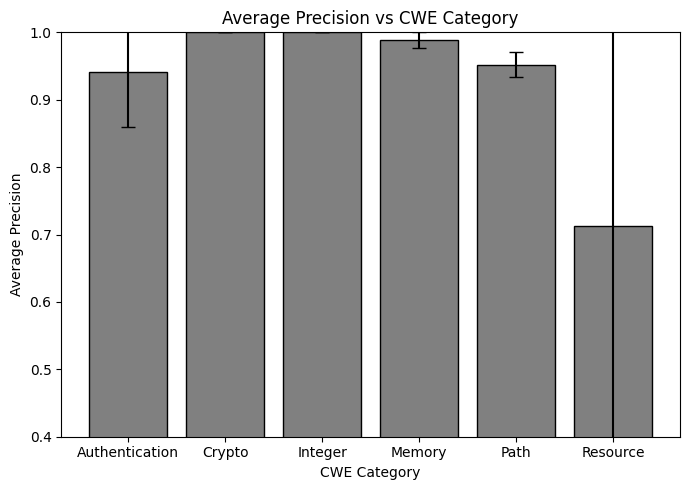

In [7]:
plt.figure(figsize=(7,5))

plt.bar(
summary["category"],
summary["mean_precision"],
yerr=summary["std_precision"],
color="grey",
edgecolor="black",
capsize=5
)

plt.ylim(0.4,1.0)

plt.xlabel("CWE Category")
plt.ylabel("Average Precision")

plt.title("Average Precision vs CWE Category")

plt.tight_layout()

plt.savefig("avg_precision_category.png",dpi=300)

plt.show()

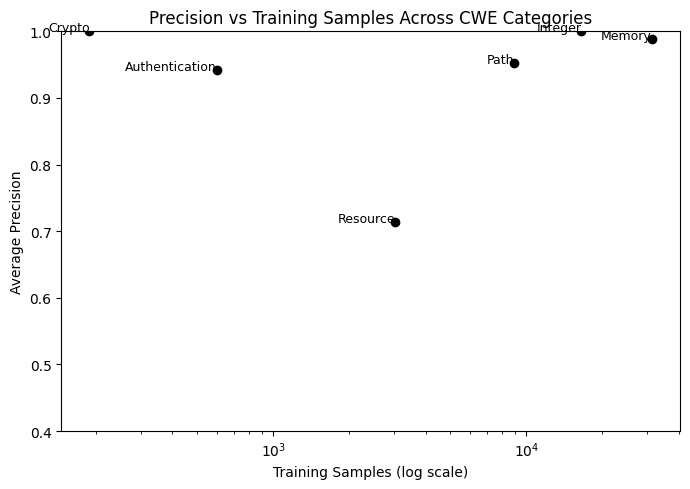

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("classification_report_updated.csv")

# CWE category mapping
cwe_category_map = {

"CWE121":"Memory",
"CWE122":"Memory",
"CWE124":"Memory",
"CWE415":"Memory",
"CWE416":"Memory",

"CWE190":"Integer",
"CWE191":"Integer",

"CWE23":"Path",
"CWE36":"Path",

"CWE259":"Authentication",
"CWE321":"Authentication",

"CWE327":"Crypto",
"CWE328":"Crypto",

"CWE404":"Resource",
"CWE400":"Resource"

}

# Map categories
df["category"] = df["label"].map(cwe_category_map)
df = df.dropna(subset=["category"])

# Aggregate by category
category_stats = df.groupby("category").agg(
    mean_precision=("precision","mean"),
    total_support=("support","sum")
).reset_index()

# Plot
plt.figure(figsize=(7,5))

plt.scatter(
    category_stats["total_support"],
    category_stats["mean_precision"],
    color="black"
)

# Annotate points
for i, row in category_stats.iterrows():
    plt.text(
        row["total_support"],
        row["mean_precision"],
        row["category"],
        fontsize=9,
        ha="right"
    )

plt.xscale("log")
plt.ylim(0.4,1.0)

plt.xlabel("Training Samples (log scale)")
plt.ylabel("Average Precision")

plt.title("Precision vs Training Samples Across CWE Categories")

plt.tight_layout()

plt.savefig("precision_vs_training_samples_category.png", dpi=300)

plt.show()

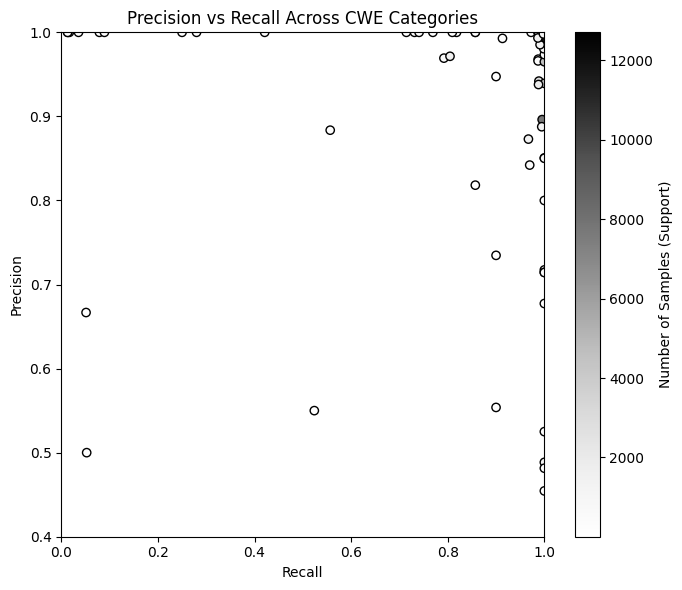

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load classification results
df = pd.read_csv("classification_report_updated.csv")

# Extract numeric CWE id if needed
df["cwe_id"] = df["label"].str.replace("CWE","").astype(int)

# Scatter plot
plt.figure(figsize=(7,6))

scatter = plt.scatter(
    df["recall"],
    df["precision"],
    c=df["support"],
    cmap="Greys",
    edgecolors="black"
)

# Label selected important CWEs
important_cwes = ["CWE79","CWE120","CWE89"]

for _, row in df.iterrows():
    if row["label"] in important_cwes:
        plt.text(
            row["recall"],
            row["precision"],
            row["label"],
            fontsize=9
        )

# Axis settings
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision vs Recall Across CWE Categories")

plt.xlim(0,1)
plt.ylim(0.4,1.0)

# Colorbar to show support size
cbar = plt.colorbar(scatter)
cbar.set_label("Number of Samples (Support)")

plt.tight_layout()

plt.savefig("precision_vs_recall_cwe.png", dpi=300)

plt.show()

/var/folders/_t/79359yk13vl8dqw3v2p08c9c0000gn/T/ipykernel_57312/2631713887.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_confusions["True_CWE"] = "CWE" + top_confusions["True_CWE"].astype(str)
/var/folders/_t/79359yk13vl8dqw3v2p08c9c0000gn/T/ipykernel_57312/2631713887.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_confusions["Predicted_CWE"] = "CWE" + top_confusions["Predicted_CWE"].astype(str)
/var/folders/_t/79359yk13vl8dqw3v2p08c9c0000gn/T/ipykernel_57312/2631713887.py:37: SettingWi

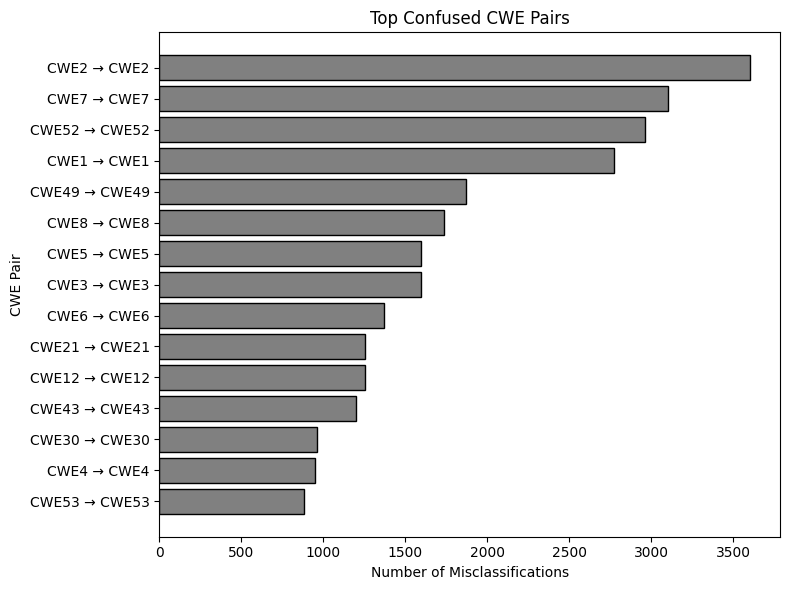

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load confusion matrix
cm = pd.read_csv("confusion_matrix.csv", index_col=0)

confusions = []

# Extract off-diagonal errors
for true_cwe in cm.index:
    for pred_cwe in cm.columns:

        if true_cwe != pred_cwe:

            count = cm.loc[true_cwe, pred_cwe]

            if count > 0:
                confusions.append((true_cwe, pred_cwe, count))


# Convert to dataframe
confusions_df = pd.DataFrame(
    confusions,
    columns=["True_CWE","Predicted_CWE","Count"]
)

# Sort
confusions_df = confusions_df.sort_values("Count", ascending=False)

# Select top 15
top_confusions = confusions_df.head(15)

# Create label column
top_confusions["True_CWE"] = "CWE" + top_confusions["True_CWE"].astype(str)
top_confusions["Predicted_CWE"] = "CWE" + top_confusions["Predicted_CWE"].astype(str)

top_confusions["pair"] = (
    top_confusions["True_CWE"] +
    " → " +
    top_confusions["Predicted_CWE"]
)

# Plot
plt.figure(figsize=(8,6))

plt.barh(
    top_confusions["pair"],
    top_confusions["Count"],
    color="grey",
    edgecolor="black"
)

plt.gca().invert_yaxis()

plt.xlabel("Number of Misclassifications")
plt.ylabel("CWE Pair")

plt.title("Top Confused CWE Pairs")

plt.tight_layout()

plt.savefig("top_confused_cwe_pairs.png", dpi=300)

plt.show()

In [12]:
print(top_confusions.dtypes)

True_CWE          int64
Predicted_CWE    object
Count             int64
dtype: object
